# non llm workflow

In [24]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [25]:
# state
class EqnState(TypedDict):
    a: int
    b: int
    c: int

    equation: str
    discriminant: float
    result :str

In [26]:
# show eqn
def show_equation(state: EqnState):
    eqn = f"{state["a"]}x**2 + {state["b"]}x + {state['c']}"
    return {"equation": eqn}

In [27]:
# calc discriminant
def calculate_discriminant(state: EqnState):
    discriminant = (state["b"]**2) - (4 * state["a"] * state["c"])
    return {"discriminant": discriminant}

In [28]:
# 2 real roots
def find_real_roots(state: EqnState):
    part1 = (-1 * state["b"]) / (2*state["a"])
    part2 = (state["discriminant"]**0.5) / (2*state["a"])

    root1 = part1+part2
    root2 = part1-part2

    return {'result': f"The real roots are {root1} and {root2}"}

# repeated roots
def find_no_roots(state: EqnState):
    root = (-1 * state["b"]) / (2*state["a"])

    return {"result": f"The repeated root is {root}"}

# imaginary roots
def find_imaginary_roots(state: EqnState):
    return {"result": f"Only the imaginary roots exist."}

In [29]:
# conditional function
def check_condition(state: EqnState) -> Literal["real_roots", "no_roots", "imaginary_roots"]:
    if state["discriminant"] > 0 :
        return "real_roots"
    elif state["discriminant"] == 0 :
        return "no_roots"
    else:
        return "imaginary_roots"

In [30]:
# graph
graph = StateGraph(EqnState)

# nodes
graph.add_node("show_eqn", show_equation)
graph.add_node("calc_discriminant", calculate_discriminant)
graph.add_node("real_roots", find_real_roots)
graph.add_node("no_roots", find_no_roots)
graph.add_node("imaginary_roots", find_imaginary_roots)

# edges
graph.add_edge(START, "show_eqn")
graph.add_edge("show_eqn", "calc_discriminant")
graph.add_conditional_edges("calc_discriminant", check_condition)
graph.add_edge("real_roots", END)
graph.add_edge("no_roots", END)
graph.add_edge("imaginary_roots", END)

# compile
workflow = graph.compile()

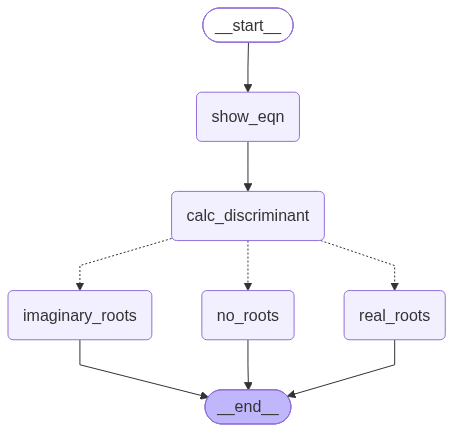

In [31]:
workflow

In [34]:
# invoke
state = {"a": 4, "b": 2, "c": 4}
response = workflow.invoke(input=state)

In [35]:
response

{'a': 4,
 'b': 2,
 'c': 4,
 'equation': '4x**2 + 2x + 4',
 'discriminant': -60,
 'result': 'Only the imaginary roots exist.'}

# LLM Based workflow : Agentic Customer Feedback Management System

In [100]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from langchain_core.output_parsers import PydanticOutputParser, StrOutputParser
from langchain_deepseek.chat_models import ChatDeepSeek
from dotenv import load_dotenv
import os
from langchain_core.runnables import RunnableSequence
from pprint import pprint

load_dotenv()
deepseek_api_key = os.getenv("DEEPSEEK_API_KEY")

In [88]:
# state
class ReviewState(TypedDict):
    review: str
    sentiment: Literal["positive", "negative", "mixed"]
    diagnosis: str
    feedback: str

In [89]:
# sentiment pydantic model
class sentiment(BaseModel):
    review_sentiment: Literal["positive", "negative", "mixed"] = Field("analyze the overall sentiment of the review and categorize it accordingly")

sentiment_parser = PydanticOutputParser(pydantic_object=sentiment)


In [90]:
# identify feedback sentiment
def identify_sentiment(state: ReviewState):
    system_prompt = """
        You are a sentiment classification system that analyzes customer product reviews.

        Your task is to classify the given customer review into exactly one of three categories:

        1. Positive — The customer expresses overall satisfaction, appreciation, praise, or a favorable opinion about the product.
        2. Negative — The customer expresses overall dissatisfaction, criticism, complaints, disappointment, or an unfavorable opinion about the product.
        3. Mixed — The customer expresses both significant positive and negative opinions about the product, without one sentiment clearly dominating the overall review.

        Instructions:
        1. Carefully analyze the overall sentiment of the review.
        2. Consider the customer's actual experience and opinion, not just individual positive or negative words.
        3. If the review is predominantly positive and contains only minor criticisms, classify it as Positive.
        4. If the review is predominantly negative and contains only minor positive comments, classify it as Negative.
        5. If the review contains significant positive and negative aspects that are both important to the customer's overall experience, classify it as Mixed.
        6. Do not classify a review as Mixed merely because it contains both positive and negative words.
        7. Determine the sentiment based on the overall tone, emphasis, and conclusion of the customer's review.
        8. Do not provide explanations, reasoning, or additional text.
        9. Return exactly one sentiment category.
        10. Your output must strictly follow the provided format instructions.

        {format_instructions}
    """

    human_prompt = """
        Analyze the following customer product review and identify the sentiment:

        Review:
        {review}
    """

    prompt_template = ChatPromptTemplate([
        ("system", system_prompt),
        ("human", human_prompt)
    ])
    chat_model = ChatDeepSeek(api_key=deepseek_api_key, model="deepseek-v4-flash")

    chain = RunnableSequence(prompt_template, chat_model, sentiment_parser)
    response = chain.invoke(input={
        "review": state["review"],
        "format_instructions": sentiment_parser.get_format_instructions()
    })

    return {"sentiment": response.review_sentiment}

In [91]:
# Diagnose positive feedback
def diagnose_positive_feedback(state: ReviewState):
    system_prompt = """
        You are a customer feedback analysis agent specialized in analyzing positive product reviews.

        Your task is to analyze a customer review that has already been classified as
        Positive and extract the key information that will be used by another LLM to
        generate an appropriate response to the customer.

        Analyze the review and identify:

        1. Main positive experience — What is the customer primarily satisfied with?
        2. Positive aspects — Identify the specific product features, qualities,
           services, or experiences that the customer appreciated.
        3. Customer benefits — Identify how the product benefited the customer or
           improved their experience, if mentioned.
        4. Specific praise — Capture any particularly important praise or appreciation
           expressed by the customer.
        5. Recommendation or loyalty — Identify whether the customer recommends the
           product or indicates an intention to purchase/use the product again.
        6. Important context — Extract any other information that would help another
           LLM write a personalized and relevant response.

        Instructions:
        - Focus only on information present in the customer review.
        - Do not invent facts, assumptions, or customer intentions.
        - Do not generate a response to the customer.
        - Do not provide solutions or suggestions.
        - Do not perform sentiment classification; the review has already been
          classified as Positive.
        - Extract meaningful information rather than repeating the entire review.
    """

    human_prompt = """
        Analyze the following customer product review:

        Review:
        {review}
    """

    prompt_template = ChatPromptTemplate([
        ("system", system_prompt),
        ("human", human_prompt)
    ])
    chat_model = ChatDeepSeek(api_key=deepseek_api_key, model="deepseek-v4-flash")

    chain = RunnableSequence(prompt_template, chat_model, StrOutputParser())
    response = chain.invoke(input={
        "review": state["review"]
    })

    return {"diagnosis": response}

In [92]:
# Diagnose negative feedback
def diagnose_negative_feedback(state: ReviewState):
    system_prompt = """
        You are a customer feedback analysis agent specialized in analyzing negative product reviews.

        Your task is to analyze a customer review that has already been classified as
        Negative and extract the key information that will be used by another LLM to
        generate an appropriate response to the customer.

        Analyze the review and identify:

        1. Main issue — What is the primary reason for the customer's dissatisfaction?
        2. Key complaints — Identify the specific problems, defects, shortcomings,
           or negative experiences mentioned by the customer.
        3. Product or service issues — Identify which product features, qualities,
           services, or expectations failed to meet the customer's needs.
        4. Customer impact — Identify how the problem affected the customer, if
           mentioned.
        5. Customer expectation or request — Identify what the customer expected,
           wanted, or requested as a resolution, if explicitly mentioned.
        6. Important context — Extract any other information that would help another
           LLM write an empathetic and relevant response.

        Instructions:
        - Focus only on information present or clearly implied in the customer review.
        - Do not invent facts, assumptions, policies, refunds, replacements, or
          solutions.
        - Do not generate a response to the customer.
        - Do not suggest a solution unless the customer explicitly requested one.
        - Do not perform sentiment classification; the review has already been
          classified as Negative.
        - Distinguish actionable complaints from general emotional expressions.
        - Prioritize the issues that are most important to the customer.
    """

    human_prompt = """
        Analyze the following customer product review:

        Review:
        {review}
    """

    prompt_template = ChatPromptTemplate([
        ("system", system_prompt),
        ("human", human_prompt)
    ])
    chat_model = ChatDeepSeek(api_key=deepseek_api_key, model="deepseek-v4-flash")

    chain = RunnableSequence(prompt_template, chat_model, StrOutputParser())
    response = chain.invoke(input={
        "review": state["review"]
    })

    return {"diagnosis": response}

In [93]:
# Diagnose mixed feedback
def diagnose_mixed_feedback(state: ReviewState):
    system_prompt = """
        You are a customer feedback analysis agent specialized in analyzing mixed product reviews.

        Your task is to analyze a customer review that has already been classified as
        Mixed and extract the key information that will be used by another LLM to
        generate an appropriate response to the customer.

        Analyze the review and identify:

        1. Positive aspects — Identify the specific features, qualities, services,
           or experiences that the customer appreciated.
        2. Negative aspects — Identify the specific problems, shortcomings, or
           disappointing experiences mentioned by the customer.
        3. Main concern — Identify the most important issue affecting the customer's
           overall experience.
        4. Customer benefits — Identify what worked well or benefited the customer,
           if mentioned.
        5. Customer impact — Identify how the negative aspects affected the customer,
           if mentioned.
        6. Customer expectation or request — Identify what the customer expected,
           wanted, or requested, if explicitly mentioned.
        7. Overall takeaway — Summarize the key points that another LLM should
           consider when preparing a balanced and appropriate response.

        Instructions:
        - Focus only on information present or clearly implied in the customer review.
        - Do not invent facts, assumptions, policies, refunds, replacements, or
          solutions.
        - Do not generate a response to the customer.
        - Do not suggest solutions unless the customer explicitly requested one.
        - Do not perform sentiment classification; the review has already been
          classified as Mixed.
        - Clearly distinguish meaningful positive and negative aspects.
        - Do not let minor positive or negative statements overshadow the important
          points of the review.
        - Prioritize the customer's most significant concerns and experiences.
    """

    human_prompt = """
        Analyze the following customer product review:

        Review:
        {review}
    """

    prompt_template = ChatPromptTemplate([
        ("system", system_prompt),
        ("human", human_prompt)
    ])
    chat_model = ChatDeepSeek(api_key=deepseek_api_key, model="deepseek-v4-flash")

    chain = RunnableSequence(prompt_template, chat_model, StrOutputParser())
    response = chain.invoke(input={
        "review": state["review"]
    })

    return {"diagnosis": response}

In [94]:
# Write a customer feedback
def write_customer_feedback(state: ReviewState):
    system_prompt = """
        You are a customer support response generation agent.

        Your task is to generate an appropriate response to a customer based on their
        sentiment and the analysis produced by a previous feedback analysis agent.

        The review has already been classified as Positive, Negative, or Mixed.
        Use the sentiment and the extracted analysis to determine the appropriate
        tone and content of the response.

        Instructions:

        1. For a Positive review:
           - Thank the customer for their positive feedback.
           - Acknowledge the specific aspects they appreciated.
           - Show genuine appreciation for their experience.
           - If they recommend the product or express loyalty, acknowledge it
             appropriately.

        2. For a Negative review:
           - Acknowledge the customer's concerns.
           - Show empathy for their negative experience.
           - Address the main issue and important complaints identified in the analysis.
           - If the customer explicitly mentioned an expectation or request,
             acknowledge it appropriately.
           - Do not dismiss, blame, or argue with the customer.

        3. For a Mixed review:
           - Acknowledge the positive aspects of the customer's experience.
           - Recognize the negative aspects and concerns.
           - Maintain a balanced and empathetic tone.
           - Do not focus only on the positive or negative aspects.

        General instructions:
        - Base the response only on the provided analysis.
        - Do not invent facts, policies, refunds, replacements, discounts, timelines,
          or other commitments.
        - Do not claim that an issue has been resolved unless the input explicitly
          states that it has been resolved.
        - Do not mention the sentiment classification or the analysis process.
        - Do not mention that another AI/model analyzed the review.
        - Keep the response professional, natural, empathetic, and concise.
        - Personalize the response using relevant details from the provided analysis.
        - Do not repeat the entire provided analysis.
        - Do not provide analysis or reasoning.
        - Return only the final response that should be sent to the customer.
    """

    human_prompt = """
        Generate an appropriate response to the customer based on the information
        provided below.

        Sentiment:
        {sentiment}

        Feedback Analysis:
        {feedback_analysis}
    """

    prompt_template = ChatPromptTemplate([
        ("system", system_prompt),
        ("human", human_prompt)
    ])
    chat_model = ChatDeepSeek(api_key=deepseek_api_key, model="deepseek-v4-flash")

    chain = RunnableSequence(prompt_template, chat_model, StrOutputParser())
    response = chain.invoke(input={
        "sentiment": state["sentiment"],
        "feedback_analysis": state["diagnosis"],
    })

    return {"feedback": response}

In [95]:
# Identify Diagnosis Type
def identify_diagnosis_type(state: ReviewState) -> Literal["run_pos_diagnosis", "run_neg_diagnosis",
        "run_mix_diagnosis"] :
    if state["sentiment"] == "positive":
        return "run_pos_diagnosis"
    elif state["sentiment"] == "negative":
        return "run_neg_diagnosis"
    else:
        return "run_mix_diagnosis"

In [96]:
# graph
graph = StateGraph(ReviewState)

# nodes
graph.add_node("identify_sentiment", identify_sentiment)

graph.add_node("run_pos_diagnosis", diagnose_positive_feedback)
graph.add_node("run_neg_diagnosis", diagnose_negative_feedback)
graph.add_node("run_mix_diagnosis", diagnose_mixed_feedback)

graph.add_node("provide_feedback", write_customer_feedback)

# edges
graph.add_edge(START, "identify_sentiment")
graph.add_conditional_edges("identify_sentiment", identify_diagnosis_type)
graph.add_edge("run_pos_diagnosis", "provide_feedback")
graph.add_edge("run_neg_diagnosis", "provide_feedback")
graph.add_edge("run_mix_diagnosis", "provide_feedback")
graph.add_edge("provide_feedback", END)

# compile
workflow = graph.compile()

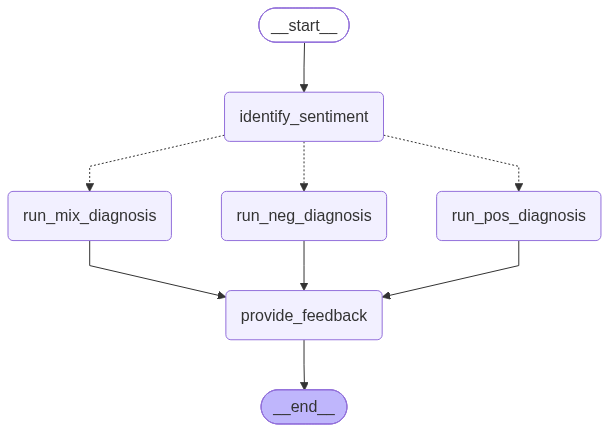

In [97]:
workflow

In [98]:
positive_review = """
I recently purchased the Apple MacBook Air with the M4 chip, 16GB of unified memory, and 256GB SSD, and I am extremely happy with the overall experience. The laptop feels premium from the moment you take it out of the box. The aluminium build is sleek, lightweight, and very well constructed, making it easy to carry around while still feeling solid and durable.

The M4 chip is the biggest highlight for me. The laptop feels incredibly responsive during everyday use, whether I am browsing the web, working with documents, attending video meetings, or running multiple applications at the same time. I also use it for programming, and it handles my development environment, terminal, browser tabs, and other tools smoothly without any noticeable lag. Switching between applications is quick, and the 16GB unified memory makes multitasking much more comfortable.

The 13.6-inch Liquid Retina display is another feature I really enjoy. The screen is sharp, bright, and produces excellent colors. Text looks very clear, which makes it particularly comfortable for reading and coding for long periods. Watching movies and videos is also a great experience because of the excellent display quality.

The keyboard is comfortable for long typing sessions, and the trackpad is one of the best I have used on a laptop. Everything feels precise and responsive. Touch ID is also extremely convenient for quickly unlocking the laptop and authenticating actions.

Battery life has been excellent for my usage. I can comfortably use the laptop for a large portion of the day for browsing, coding, watching videos, and general productivity without constantly worrying about finding a power outlet. The fanless design also makes normal usage remarkably quiet.

Another major advantage is its portability. The MacBook Air is thin and lightweight enough to carry everywhere, but it still provides more than enough performance for my daily work. The combination of performance, battery life, display quality, keyboard, trackpad, and portability makes it a very well-balanced laptop.

The only limitation I have noticed is the 256GB storage, which can feel restrictive if you work with large datasets, videos, or many applications. However, for my normal work and development needs, it has been sufficient so far.

Overall, I am extremely satisfied with the MacBook Air M4. It is fast, quiet, lightweight, reliable, and has excellent battery life. The build quality and user experience are also outstanding. For students, developers, professionals, and anyone looking for a premium everyday laptop, I would definitely recommend it.
"""

negative_review = """
I purchased the **Apple MacBook Air 13-inch with the M4 chip, 16GB unified memory, and 256GB SSD**, expecting a smooth and reliable experience, but unfortunately, the laptop has several shortcomings that have made me question whether it was worth the price.

The biggest issue for me is the **256GB storage capacity**. While the laptop performs well initially, the available storage becomes limiting very quickly. After installing development tools, applications, and storing project files, a significant portion of the storage is already occupied. For anyone working with large datasets, videos, virtual machines, or multiple development environments, 256GB can become frustratingly restrictive. Considering the premium price of the laptop, I expected more storage as standard.

I also find the **limited number of ports** inconvenient. Having to rely on adapters or hubs whenever I need to connect external storage, a monitor, or other peripherals makes the laptop less convenient for my workflow. A laptop at this price point should ideally provide more flexibility for connecting commonly used accessories.

Another disappointment is the **lack of upgradeability**. The memory and internal storage cannot be upgraded after purchase, so choosing the right configuration at the time of purchase is extremely important. If your requirements increase later, you essentially have to work around the limitations or purchase another machine.

The laptop is also not ideal for **heavy workloads**. While it handles everyday tasks and programming very well, demanding workloads can expose its limitations. Sustained intensive processing can result in reduced performance compared with larger laptops designed with more substantial cooling systems. This is something I did not fully appreciate before buying it.

The **macOS ecosystem** also took some time to get used to. Some applications and tools that I regularly used on other platforms either required different versions, alternative software, or additional configuration. This can be frustrating if you are moving from another operating system and depend on specific applications.

Another issue is the **price**. The MacBook Air provides a premium experience, but once you add additional storage or accessories such as adapters and external drives, the overall cost becomes considerably higher. At this price range, I expected fewer compromises.

Overall, although the MacBook Air M4 has excellent performance, build quality, battery life, and a beautiful display, I feel that the limited storage, restricted connectivity, lack of upgradeability, and relatively high overall cost significantly reduce its value for my particular use case. It may be an excellent laptop for many users, but I would recommend carefully considering your storage, connectivity, and workload requirements before purchasing it.
"""


mixed_review = """
I recently purchased the **Apple MacBook Air 13-inch with the M4 chip, 16GB unified memory, and 256GB SSD**, and my experience has been a mix of positives and negatives.

On the positive side, the laptop has excellent build quality. It feels premium, lightweight, and very well constructed. The M4 chip provides impressive performance for everyday tasks, programming, browsing, video calls, and multitasking. Applications open quickly, and switching between multiple applications is generally smooth. The 16GB unified memory is also helpful when running a development environment alongside several browser tabs and other applications.

The display is another strong point. It is sharp, bright, and produces excellent colors. Text is easy to read, which makes it comfortable for coding and working for long periods. The keyboard and trackpad are also excellent. The keyboard is comfortable for extended typing sessions, while the trackpad is accurate and responsive.

Battery life has been very good for my normal usage. I can work for several hours without constantly looking for a power outlet, and the fanless design makes the laptop extremely quiet during regular tasks. Portability is another major advantage because the laptop is thin and light enough to carry around easily.

However, there are some significant drawbacks. The biggest problem for me is the **256GB SSD**. The storage fills up surprisingly quickly after installing development tools, applications, and storing project files. Since the internal storage cannot be upgraded later, choosing a higher-capacity configuration becomes important, but that also increases the already high price.

The limited number of ports is another inconvenience. I frequently need an adapter or hub to connect external devices, which adds extra cost and makes the setup less convenient. I also feel that the laptop is better suited to everyday productivity and moderate workloads than sustained heavy processing. It handles my normal programming tasks well, but demanding workloads can expose its limitations.

The price is another factor I struggled with. The overall experience is polished and premium, but once you add more storage and necessary accessories, the cost becomes quite high. At this price point, I expected fewer compromises.

Overall, I really like the MacBook Air M4 for its **performance, battery life, display, portability, keyboard, and build quality**, but I am less satisfied with the **limited storage, connectivity options, upgradeability, and overall cost**. It is a great laptop in many respects, but it is not perfect. I would recommend it to someone who values portability and battery life, but I would strongly suggest considering a higher storage configuration if you plan to use it for development or storing large files.
"""

In [110]:
# invoke positive review
state = {"review": positive_review}
response = workflow.invoke(input=state)

print("Sentiment :", response["sentiment"])
print("-"*200)
print("Diagnosis :\n", response["diagnosis"])
print("-"*200)
print("Feedback :\n", response["feedback"])

Sentiment : positive
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Diagnosis :
 ### Analysis of the Customer Review

**1. Main positive experience**  
The customer is extremely satisfied with the overall experience of the Apple MacBook Air with the M4 chip. The laptop exceeded expectations in performance, build quality, display, battery life, and portability.

**2. Positive aspects**  
- Premium aluminium build: sleek, lightweight, well constructed, solid, durable  
- M4 chip: highly responsive for everyday use, programming, multitasking, and running multiple applications without lag  
- 16GB unified memory: made multitasking more comfortable  
- 13.6-inch Liquid Retina display: sharp, bright, excellent colors, very clear text  
- Keyboard: comfortable for long typing sessions  
- Trackpad: one of the best used on a laptop; precise a

In [111]:
# invoke negative review
state = {"review": negative_review}
response = workflow.invoke(input=state)

print("Sentiment :", response["sentiment"])
print("-"*200)
print("Diagnosis :\n", response["diagnosis"])
print("-"*200)
print("Feedback :\n", response["feedback"])

Sentiment : negative
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Diagnosis :
 ### 1. Main Issue

The customer’s primary dissatisfaction is the **256GB storage capacity**, which they describe as “the biggest issue.” It quickly becomes restrictive for their development and data-heavy workload, and this is made worse by the fact that storage cannot be upgraded later.

Other significant issues include limited connectivity, lack of upgradeability, reduced performance under sustained heavy workloads, macOS ecosystem friction, and high overall cost.

---

### 2. Key Complaints

**Actionable complaints:**

- **Insufficient storage:** 256GB fills up quickly after installing development tools, applications, and project files.
- **Limited ports:** The customer has to use adapters or hubs for external storage, monitors, and peripherals.
- **No

In [112]:
# invoke mixed review
state = {"review": mixed_review}
response = workflow.invoke(input=state)

print("Sentiment :", response["sentiment"])
print("-"*200)
print("Diagnosis :\n", response["diagnosis"])
print("-"*200)
print("Feedback :\n", response["feedback"])

Sentiment : mixed
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Diagnosis :
 **Positive aspects**
- Excellent build quality; feels premium, lightweight, and well constructed.
- M4 chip delivers strong performance for everyday tasks, programming, browsing, video calls, and multitasking.
- 16GB unified memory supports running a development environment alongside multiple browser tabs and applications.
- Display is sharp, bright, with excellent colors; comfortable for coding and long working sessions.
- Keyboard is comfortable for extended typing; trackpad is accurate and responsive.
- Battery life is very good for normal usage, allowing several hours away from a power outlet.
- Fanless design keeps the laptop extremely quiet during regular tasks.
- Portability is a major advantage due to the thin and light design.

**Negative aspects**
